# AR Characteristics EDA

A little EDA to explore any possible patterns in AR characteristics and geographic distributions, etc.

In [15]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib import animation
from IPython.display import Video
import pandas as pd
import sklearn.cluster as cluster
import dask.array as da

In [6]:
from IPython.display import display, Markdown
import warnings
import os
import requests
import s3fs
import boto3
from subprocess import Popen
from getpass import getpass
from netrc import netrc

In [7]:
if (boto3.client('s3').meta.region_name == 'us-west-2'):
    display(Markdown('### us-west-2 Region Check: &#x2705;'))
else:
    display(Markdown('### us-west-2 Region Check: &#10060;'))
    raise ValueError('Your notebook is not running inside the AWS us-west-2 region, and will not be able to directly access NASA Earthdata S3 buckets')

### us-west-2 Region Check: &#x2705;

In [8]:
urs = 'urs.earthdata.nasa.gov'    # Earthdata URL endpoint for authentication
prompts = ['Enter NASA Earthdata Login Username: ',
           'Enter NASA Earthdata Login Password: ']

netrc_name = ".netrc"

# Determine if netrc file exists, and if so, if it includes NASA Earthdata Login Credentials
try:
    netrcDir = os.path.expanduser(f"~/{netrc_name}")
    # Check credentials against URS, and if username exists
    netrc(netrcDir).authenticators(urs)[0]

# Below, create a netrc file and prompt user for NASA Earthdata Login Username and Password
except FileNotFoundError:
    homeDir = os.path.expanduser("~")
    Popen('touch {0}{2} | echo machine {1} >> {0}{2}'.format(homeDir + os.sep, urs, netrc_name), shell=True)
    Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
    Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)
    # Set restrictive permissions
    Popen('chmod 0600 {0}{1}'.format(homeDir + os.sep, netrc_name), shell=True)

In [9]:
gesdisc_s3 = "https://data.gesdisc.earthdata.nasa.gov/s3credentials"

# Define a function for S3 access credentials

def begin_s3_direct_access(url: str=gesdisc_s3):
    response = requests.get(url).json()
    return s3fs.S3FileSystem(key=response['accessKeyId'],
                             secret=response['secretAccessKey'],
                             token=response['sessionToken'],
                             client_kwargs={'region_name':'us-west-2'})

fs = begin_s3_direct_access()

# Check that the file system is intact as an S3FileSystem object, which means that token is valid
# Common causes of rejected S3 access tokens include incorrect passwords stored in the netrc file, or a non-existent netrc file
type(fs)

s3fs.core.S3FileSystem

In [68]:
links_file = open('/home/jovyan/extreme_antarctic_ARs/data/merra2/subset_M2I1NXASM_5.12.4_20240413_033655_S3URLs.txt')
links_lst = links_file.readlines()
links_lst = [link.strip() for link in links_lst]

In [76]:
years = np.arange(1980, 1981)
ar_catalog_names = sorted(os.listdir('/home/jovyan/extreme_antarctic_ARs/data/ar_catalogs/'))

In [ ]:
# full range of dates of MERRA2

path = '~/extreme_antarctic_ARs/data/ar_catalogs/'

for i in range(len(years)):

    dataarrays = []
    
    day_ct = 0
    
    year = years[i]
    ar_catalog_name = ar_catalog_names[i]
    ar_catalog = xr.open_mfdataset(path+ar_catalog_name)

    num_days = 365
    if year % 4 == 0:
        num_days = 366

    print('starting year')
        
    for j in range(day_ct, day_ct + num_days):
        dat = xr.open_dataset(fs.open(links_lst[j]), decode_cf=True,)
        antarctic_dat = dat.sel(lat = slice(-90.0, -50.0), lon = slice(-180, 179.4))
        sub_dat = antarctic_dat[['TQV', 'V10m', 'T10m']]
        dataarrays.append(sub_dat)

    day_ct = day_ct + num_days
    tot_datarray = xr.concat(objs=list(daily_xr_datasets.values()), dim='time')

    print('finishing year')
    

<File-like object S3FileSystem, gesdisc-cumulus-prod-protected/MERRA2/M2I1NXASM.5.12.4/1980/01/MERRA2_100.inst1_2d_asm_Nx.19800103.nc4>

In [56]:
dat = xr.open_dataset(fs.open(links_lst[1]), decode_cf=True,)

In [ ]:
j

In [33]:
path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
fn = 'MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.20220101-20221231.nc'
ar_catalog = xr.open_mfdataset(path+fn)
ar_binary_tag = ar_catalog.ar_binary_tag
#total_dat = xr.merge([ar_catalog, tot_dataset], join='inner')

In [34]:
ar_binary_tag

<xarray.DataArray 'ar_binary_tag' (time: 2920, lat: 361, lon: 576)> Size: 607MB
dask.array<open_dataset-ar_binary_tag, shape=(2920, 361, 576), dtype=int8, chunksize=(1, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 23kB 2022-01-01 ... 2022-12-31T21:00:00
Attributes:
    scheme:        Wille_vIVT
    description:   Binary indicator of atmospheric river using vIVT
    version:       2.4
    credits:       Developed by Jonathan D. Wille, Ambroise Dufour, Jai Chowd...
    cell_methods:  time: mean

In [116]:
# clustering ARs using DBSCAN

path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
fn = 'MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.19800101-19801231.nc' # the files are annual
ds2 = xr.open_mfdataset(path+fn)
ar_binary_tag = ds2.ar_binary_tag.sel(time=slice('1980-01-01T18:00','1980-01-07T18:00'))

In [119]:
ar_pts = np.argwhere(ar_binary_tag.to_numpy() == 1)

In [123]:
ar_pts

array([[  1, 255, 345],
       [  1, 255, 346],
       [  1, 255, 347],
       ...,
       [ 48,  92, 494],
       [ 48,  93, 492],
       [ 48,  93, 493]])

In [ ]:
db_obj.labels_

In [92]:
first_ar = ar_pts[db_obj.labels_ == 1]

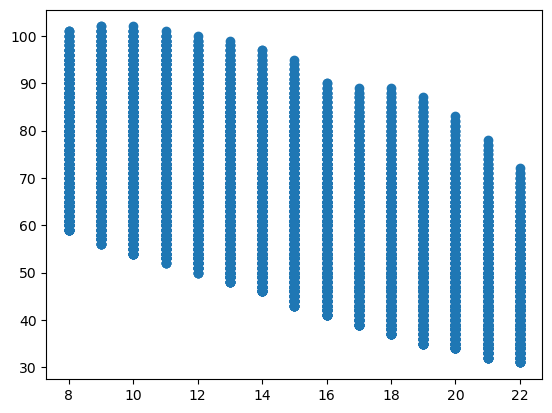

In [93]:
plt.scatter(first_ar[:,0], first_ar[:,1])

## Antarctic-wide